When changing from "delta" to "epsilon". Check that the implementation is correct:

That is, 2pi - delta is similar to epsilon.

Epsilon is the distance threshold

delta is the distance from 2 pi 

In theory, epsilon = 2 pi - delta

In [1]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 14        # default for all text
mpl.rcParams['axes.titlesize'] = 16   # title
mpl.rcParams['axes.labelsize'] = 14   # x/y labels
mpl.rcParams['xtick.labelsize'] = 14  # x tick labels
mpl.rcParams['ytick.labelsize'] = 14  # y tick labels

In [2]:
from pathlib import Path
import os
import sys

# Resolve repository root so module imports work from nested notebook folders.
cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root != repo_root.parent and not (repo_root / "constants.py").exists():
    repo_root = repo_root.parent

if not (repo_root / "constants.py").exists():
    raise FileNotFoundError("Could not find repository root containing constants.py")

os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)

import importlib
import toroidal_coordinates.epsilon as eps
importlib.reload(eps)
from toroidal_coordinates.epsilon import *

Repository root: /home/hyoon/GridCellDecoding


In [3]:
FIGS_DIR = "revision/sweep_epsilon/plot_epsilon_selection/"

# 1. Check that compute_delta and compute_epsilon agee
* `compute_delta` used to be called `compute_epsilon` in old code
* `epsilon` is the threshold 
* `delta` = 2 pi - epsilon

## 1(a) Check simulation

In [15]:
from pathlib import Path
import pickle
import numpy as np

base_dir = Path("/data/hyoon/GridDecode/grid_fields/")


trace_path = base_dir / "1_world_n1_results.npz"
toroidal_coords_path = base_dir / "1_world_n1_toroidal_coords_dreimac.npz"

# load trace
with np.load(trace_path) as data:
    print("Available keys in the npz file:", data.files)
    processed_trace = data["processed_trace"]

# load toroidal coords (from DREIMAC)
with np.load(toroidal_coords_path) as data:
    print("Available keys in the npz file:", data.files)
    toroidal_coords = data["tor_coord_dreimac"]


print(f"Loaded: {toroidal_coords_path}")
if hasattr(toroidal_coords, "shape"):
    print("toroidal_coords shape:", toroidal_coords.shape)
else:
    print("npz keys:", list(toroidal_coords.keys()))


# compute toroidal coords
coords = toroidal_coords

Available keys in the npz file: ['processed_trace', 'tor_coord_gardner', 'lifted_coord_gardner', 'score_gardner']
Available keys in the npz file: ['tor_coord_dreimac']


Loaded: /data/hyoon/GridDecode/grid_fields/1_world_n1_toroidal_coords_dreimac.npz
toroidal_coords shape: (599998, 2)


In [16]:
# plot the epsilon parameter selected
cir_coords = coords
fit_range = 1/3
disposition = np.abs(cir_coords[1:] - cir_coords[:-1])      # (T-1, 2)

# 2) Largest displacement per time step
large_disposition = np.max(disposition, axis=1)             # (T-1,)

cutoff = 2 * np.pi * fit_range
kept = large_disposition[large_disposition >= cutoff]

In [25]:
epsilon = compute_epsilon(cir_coords)
print("epsilon:", epsilon)

epsilon: 5.246902968358795


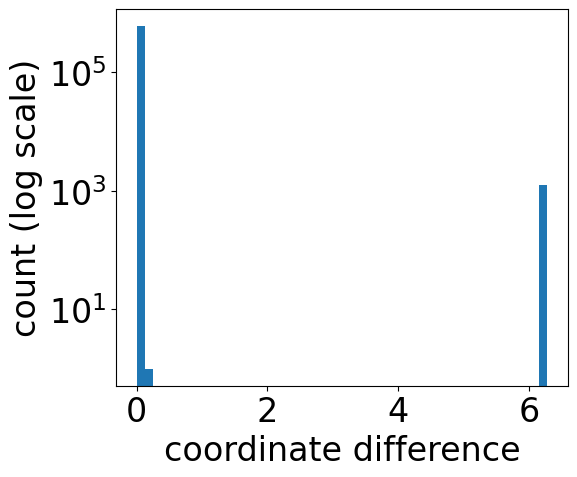

In [22]:
fig, ax = plt.subplots(figsize = (6,5))
ax.hist(large_disposition, bins=50)
ax.set_yscale('log')

ax.set_xlabel("coordinate difference", fontsize=24)
ax.set_ylabel("count (log scale)", fontsize=24)
# ax.set_title("Histogram of coordinate differences, \n simulated data", fontsize=20)
ax.tick_params(axis='x', labelsize=24)
ax.tick_params(axis='y', labelsize=24)

fig.tight_layout()

plt.savefig(FIGS_DIR + "histogram_coordinate_differences_simulation.png", bbox_inches='tight')
plt.show()

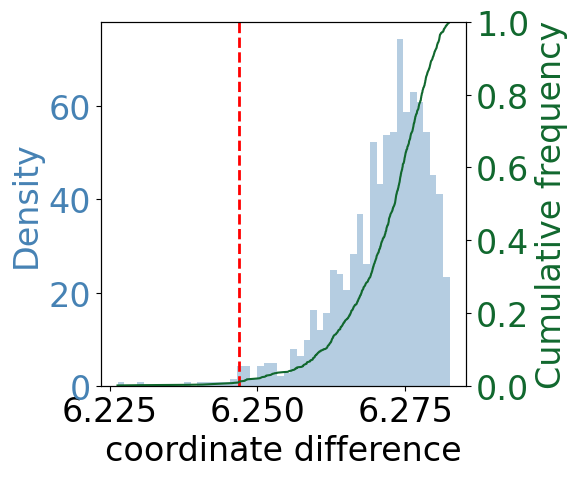

In [27]:
fig, ax1 = plt.subplots(figsize = (6,5))

# Normalized histogram on left axis
ax1.hist(kept, bins=50, density=True, alpha=0.4, color='steelblue',) #label='Density')
ax1.set_xlabel('coordinate difference', fontsize=24)
ax1.set_ylabel('Density', color='steelblue', fontsize=24)
ax1.tick_params(axis='y', labelcolor='steelblue', labelsize=24)
ax1.tick_params(axis='x', labelsize=24)


# CDF on right axis
ax2 = ax1.twinx()
sorted_kept = np.sort(kept)
cumfreq = np.arange(1, len(sorted_kept) + 1) / len(sorted_kept)
ax2.plot(sorted_kept, cumfreq, color="#11682E", label='CDF')
ax2.set_ylabel('Cumulative frequency', color="#11682E", fontsize=24)
ax2.tick_params(axis='y', labelcolor="#11682E", labelsize=24)
ax2.set_ylim(0, 1)

# Vertical line at epsilon
ax1.axvline(epsilon+1, color="red", linestyle='--', linewidth = 2 )#label=f'epsilon = {epsilon+1:.3f}')
#ax1.legend(loc='upper left')

#plt.title('Histogram and CDF of kept values')
fig.tight_layout()
plt.savefig(FIGS_DIR + "histogram_cdf_kept_values_simulation.png", bbox_inches='tight')
plt.show()


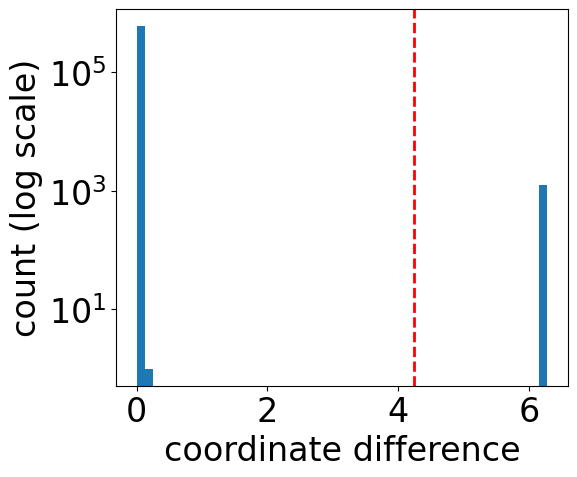

In [29]:
# the true epsilon (used as distance threshold) is epsilon - 2

fig, ax = plt.subplots(figsize = (6,5))
ax.hist(large_disposition, bins=50)
ax.set_yscale('log')
ax.set_xlabel("coordinate difference", fontsize=24)
ax.set_ylabel("count (log scale)", fontsize=24)
ax.tick_params(axis='x', labelsize=24)
ax.tick_params(axis='y', labelsize=24)
# ax.set_title("Histogram of coordinate differences, simulated data")
ax.axvline(x=epsilon - 1, color="red", linestyle="--", linewidth = 2)

fig.tight_layout()
plt.savefig(FIGS_DIR + "histogram_coordinate_differences_simulation_with_epsilon.png", bbox_inches='tight')
plt.show()

## 1(b) Check 2D Gardner data

In [75]:
import os, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

sys.path.append('.')
from constants import GARDNER_DATA_PATH
from Gardner_data_test.utils import get_spikes
from Gardner_data_test.Gardner_lifting_test import interpolate_2d_along_axis_0
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from toroidal_coordinates.compute_coord import interp_arr
from pipelines import (
    recover_traj_pipeline,
    compare_lifted_pipeline,
    segmental_compare_pipeline,
    plot_trajectory_comparison,
)

In [76]:
RAT_NAME  = 'R'
MOD_NAME  = '1'
SESS_NAME = 'OF'
DAY_NAME  = 'day2'

sspikes, xx, yy, _, _ = get_spikes(
    RAT_NAME, MOD_NAME, DAY_NAME, SESS_NAME,
    bType='pure', bSmooth=True, bSpeed=True,
    folder=GARDNER_DATA_PATH,
)
original_coord = np.column_stack((xx, yy))

print(f"Spike matrix shape: {sspikes.shape}  (n_timesteps x n_cells)")
print(f"Position arrays: xx={xx.shape}, yy={yy.shape}")

# compute toroidal coords
tor_coord, _ = recover_traj_pipeline(sspikes.T)

Spike matrix shape: (126728, 111)  (n_timesteps x n_cells)
Position arrays: xx=(126728,), yy=(126728,)
dreimac failed, falling back to gardner


/home/hyoon/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:150: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 0.5186296604861926


In [77]:
# check. We want 2pi - delta to be close to epsilon
delta = compute_delta(tor_coord)
epsilon = compute_epsilon(tor_coord)

print("delta:", delta)
print("2 pi - delta:", 2 * np.pi - delta)
print("epsilon:", epsilon)

delta: 4.779335962268521
2 pi - delta: 1.5038493449110648
epsilon: 1.5186296604861926


In [78]:
# plot the epsilon parameter selected
cir_coords = tor_coord
fit_range = 1/3
disposition = np.abs(cir_coords[1:] - cir_coords[:-1])      # (T-1, 2)

# 2) Largest displacement per time step
large_disposition = np.max(disposition, axis=1)             # (T-1,)

cutoff = 2 * np.pi * fit_range
kept = large_disposition[large_disposition >= cutoff]

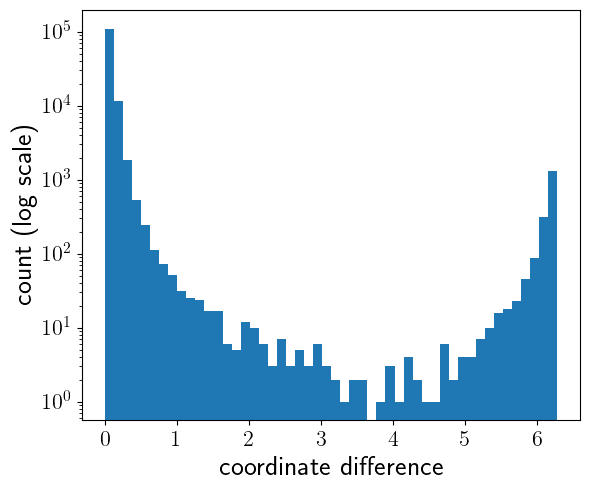

In [82]:
fig, ax = plt.subplots(figsize = (6,5))
ax.hist(large_disposition, bins=50)
ax.set_yscale('log')

ax.set_xlabel("coordinate difference", fontsize=20)
ax.set_ylabel("count (log scale)", fontsize=20)
# ax.set_title("Histogram of coordinate differences, \n simulated data", fontsize=20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

fig.tight_layout()

plt.savefig(FIGS_DIR + "2D_experimental_histogram_coordinate_differences.png", bbox_inches='tight')
plt.show()


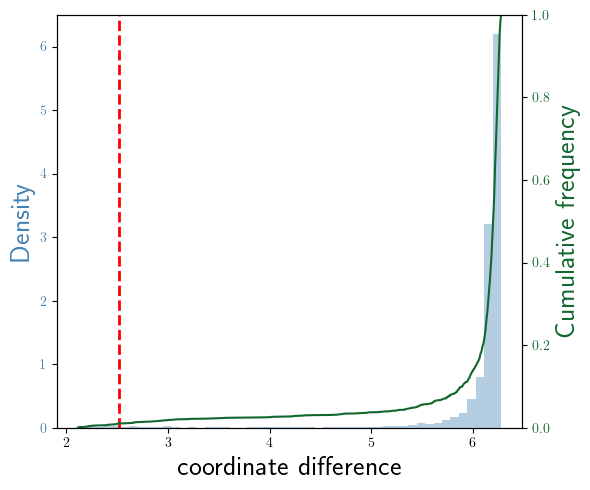

In [80]:
fig, ax1 = plt.subplots(figsize = (6,5))

# Normalized histogram on left axis
ax1.hist(kept, bins=50, density=True, alpha=0.4, color='steelblue',) #label='Density')
ax1.set_xlabel('coordinate difference', fontsize=20)
ax1.set_ylabel('Density', color='steelblue', fontsize=20)
ax1.tick_params(axis='y', labelcolor='steelblue', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)


# CDF on right axis
ax2 = ax1.twinx()
sorted_kept = np.sort(kept)
cumfreq = np.arange(1, len(sorted_kept) + 1) / len(sorted_kept)
ax2.plot(sorted_kept, cumfreq, color="#11682E", label='CDF')
ax2.set_ylabel('Cumulative frequency', color="#11682E", fontsize=20)
ax2.tick_params(axis='y', labelcolor="#11682E", labelsize=16)
ax2.set_ylim(0, 1)

# Vertical line at epsilon
ax1.axvline(epsilon+1, color="red", linestyle='--', linewidth = 2 )#label=f'epsilon = {epsilon+1:.3f}')
#ax1.legend(loc='upper left')

#plt.title('Histogram and CDF of kept values')
fig.tight_layout()
plt.savefig(FIGS_DIR + "2D_experimental_histogram_cdf_kept_values.png", bbox_inches='tight')
plt.show()


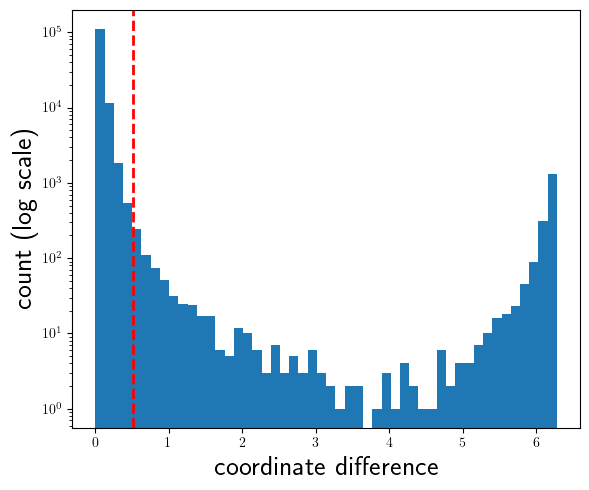

In [83]:
# the true epsilon (used as distance threshold) is epsilon - 2

fig, ax = plt.subplots(figsize = (6,5))
ax.hist(large_disposition, bins=50)
ax.set_yscale('log')
ax.set_xlabel("coordinate difference", fontsize=20)
ax.set_ylabel("count (log scale)", fontsize=20)
# ax.set_title("Histogram of coordinate differences, simulated data")
ax.axvline(x=epsilon - 1, color="red", linestyle="--", linewidth = 2)

fig.tight_layout()
plt.savefig(FIGS_DIR + "2D_experimental_histogram_coordinate_differences_with_epsilon.png", bbox_inches='tight')
plt.show()